In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

In [3]:
base_path = r'/content/drive/MyDrive/archive (26)'
for root, dirs, files in os.walk(base_path):
    level = root.replace(base_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/ (Files: {len(files)})')

archive (26)/ (Files: 1)
    Bone_Fracture_Binary_Classification/ (Files: 0)
        Bone_Fracture_Binary_Classification/ (Files: 0)
            test/ (Files: 0)
                not fractured/ (Files: 268)
                fractured/ (Files: 238)
            train/ (Files: 0)
                not fractured/ (Files: 4640)
                fractured/ (Files: 4606)
            val/ (Files: 0)
                not fractured/ (Files: 492)
                fractured/ (Files: 337)


In [4]:
data_list = []
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith(('.png', '.jpg', '.jpeg')):
            path_parts = root.split(os.sep)
            label = path_parts[-1]
            region = path_parts[-2]
            data_list.append({'Region': region, 'Label': label})
df = pd.DataFrame(data_list)

In [5]:
summary = df.groupby(['Region', 'Label']).size().reset_index(name='Count')
summary['Percentage'] = (summary['Count'] / summary['Count'].sum()) * 100
print("*"*3,"Data distribution summary ","*"*3)
print(summary)

*** Data distribution summary  ***
  Region          Label  Count  Percentage
0   test      fractured    238    2.249315
1   test  not fractured    268    2.532842
2  train      fractured   4606   43.530857
3  train  not fractured   4640   43.852188
4    val      fractured    337    3.184954
5    val  not fractured    492    4.649844


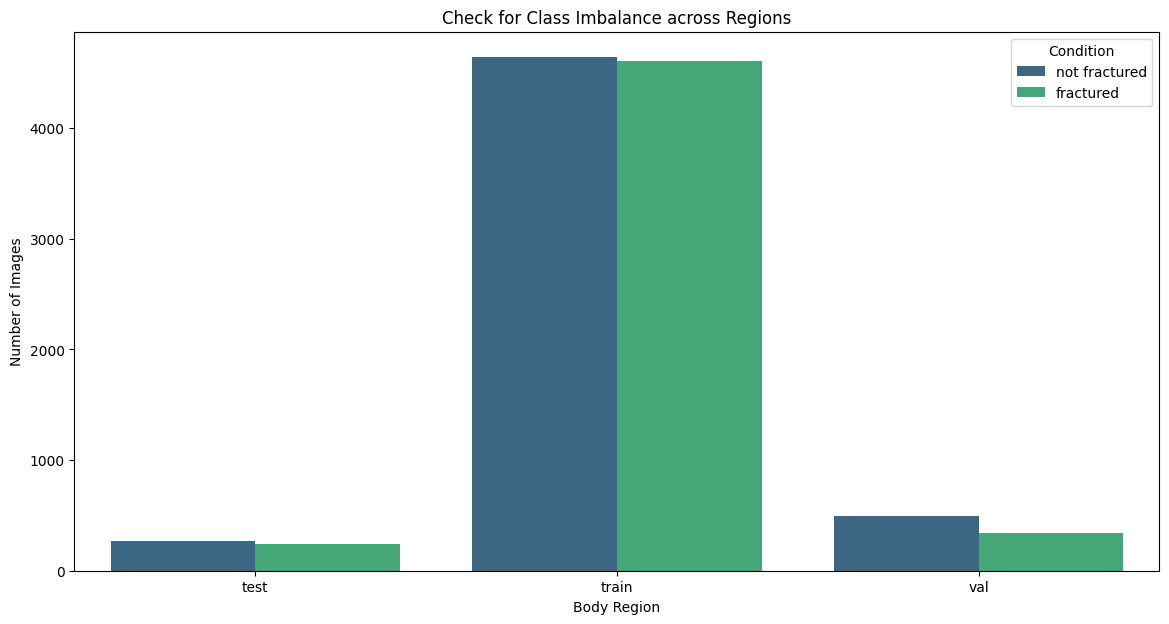

In [6]:
plt.figure(figsize=(14, 7))
sns.countplot(data=df, x='Region', hue='Label', palette='viridis')
plt.title('Check for Class Imbalance across Regions')
plt.xlabel('Body Region')
plt.ylabel('Number of Images')
plt.legend(title='Condition')
plt.show()

In [7]:
from collections import Counter

def check_extensions(path):
    report = {}
    for root, dirs, files in os.walk(path):
        if files:
            extensions = [os.path.splitext(f)[1].lower() for f in files]
            folder_name = os.path.relpath(root, path)
            report[folder_name] = Counter(extensions)
    return report

extensions_report = check_extensions(base_path)
for folder, counts in extensions_report.items():
    counts_str = ", ".join([f"{ext}: {count}" for ext, count in counts.items()])
    print(f"{folder:<50} | {counts_str}")

.                                                  | .txt: 1
Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/not fractured | .jpg: 250, .png: 18
Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/fractured | .jpg: 199, .png: 39
Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured | .jpg: 4613, .png: 27
Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/fractured | .jpg: 4530, .png: 48, .jpeg: 28
Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/val/not fractured | .png: 18, .jpg: 474
Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/val/fractured | .jpg: 265, .png: 41, .jpeg: 31


In [11]:
duplicate_count = df.duplicated().sum()
print(f"Total number of duplicate rows: {duplicate_count}")
data_list = []
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith(('.png', '.jpg', '.jpeg')):
            path_parts = root.split(os.sep)
            label = path_parts[-1]
            region = path_parts[-2]
            data_list.append({'File': file, 'Region': region, 'Label': label})

df = pd.DataFrame(data_list)

real_duplicates = df.duplicated().sum()
print(f"The actual number of duplicate images: {real_duplicates}")

if real_duplicates > 0:
    print("Details of duplicate data:")
    print(df[df.duplicated()])

Total number of duplicate rows: 0
The actual number of duplicate images: 0


In [8]:
def get_folder_pixels(path):
    folder_reports = []

    for root, dirs, files in os.walk(path):
        images = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if images:
            folder_name = os.path.relpath(root, path)
            resolutions = []

            for img_name in images:
                img_path = os.path.join(root, img_name)
                try:
                    with Image.open(img_path) as img:
                        resolutions.append(img.size)
                except:
                    continue

            if resolutions:
                df_res = pd.DataFrame(resolutions, columns=['Width', 'Height'])

                report = {
                    'Folder': folder_name,
                    'Total Images': len(images),
                    'Min Pixels': f"{df_res['Width'].min()}x{df_res['Height'].min()}",
                    'Max Pixels': f"{df_res['Width'].max()}x{df_res['Height'].max()}",
                    'Avg Pixels': f"{int(df_res['Width'].mean())}x{int(df_res['Height'].mean())}"
                }
                folder_reports.append(report)

    return pd.DataFrame(folder_reports)

pixel_report = get_folder_pixels(base_path)
pixel_report

,Folder,Total Images,Min Pixels,Max Pixels,Avg Pixels
0,Bone_Fracture_Binary_Classification/Bone_Fract...,268,224x224,2460x2970,560x666
1,Bone_Fracture_Binary_Classification/Bone_Fract...,238,224x224,2328x2928,428x490
2,Bone_Fracture_Binary_Classification/Bone_Fract...,4640,224x224,2460x3764,260x273
3,Bone_Fracture_Binary_Classification/Bone_Fract...,4606,100x100,4232x5823,290x314
4,Bone_Fracture_Binary_Classification/Bone_Fract...,492,224x224,2460x2970,412x471
5,Bone_Fracture_Binary_Classification/Bone_Fract...,337,100x100,3000x4403,506x580


In [12]:
base_path = r'path_to_your_original_data'
output_path = r'C:\Users\HP\Downloads\Processed_Dataset'
target_size = (224, 224)
def resize_with_padding(img, size):
    h, w = img.shape[:2]
    sh, sw = size

    aspect = w / h
    if aspect > 1:
        # new_w = sw
        new_h = np.round(new_w / aspect).astype(int)
    else:
        new_h = sh
        new_w = np.round(new_h * aspect).astype(int)

    scaled_img = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)

    top = (sh - new_h) // 2
    bottom = sh - new_h - top
    left = (sw - new_w) // 2
    right = sw - new_w - left

    padded_img = cv2.copyMakeBorder(scaled_img, top, bottom, left, right, cv2.BORDER_CONSTANT, value=[0, 0, 0])
    return padded_img


for root, dirs, files in os.walk(base_path):
    image_files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    if image_files:
        rel_path = os.path.relpath(root, base_path)
        target_dir = os.path.join(output_path, rel_path)
        os.makedirs(target_dir, exist_ok=True)

        print(f" {rel_path}( {len(image_files)})")

        for img_name in image_files:
            img_path = os.path.join(root, img_name)
            img = cv2.imread(img_path)

            if img is not None:
                final_img = resize_with_padding(img, target_size)
                save_name = os.path.splitext(img_name)[0] + ".jpg"
                cv2.imwrite(os.path.join(target_dir, save_name), final_img)

print(f"\n The process was successful! All images are now in size. {target_size} It is in the folder: {output_path}")


 The process was successful! All images are now in size. (224, 224) It is in the folder: C:\Users\HP\Downloads\Processed_Dataset


In [13]:
path_parts = root.split(os.sep)
label = path_parts[-1]
region = path_parts[-2]

data_list = []
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith(('.png', '.jpg', '.jpeg')):
            path_parts = root.split(os.sep)
            label = path_parts[-1]   # fractured أو not fractured
            split_type = path_parts[-2] # train أو test أو val
            region = path_parts[-3] if len(path_parts) > 3 else "Unknown"
            data_list.append({
                'Split': split_type,
                'Region': region,
                'Label': label,
                'File_Name': file
            })

In [15]:
import os
import pandas as pd

base_path = '/content/drive/MyDrive/archive (26)' # Explicitly set the correct base_path
output_path = os.path.join(base_path, 'Bone_Fracture_Binary_Classification', 'Bone_Fracture_Binary_Classification')
processed_data = []

for root, dirs, files in os.walk(output_path):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            path_parts = root.split(os.sep)

            label = path_parts[-1]
            full_path = os.path.join(root, file)
            processed_data.append(
                {
                    'Path': full_path,
                    'Label': label,
                    'Split': path_parts[-2]
                }
            )

df_final = pd.DataFrame(processed_data)

print("Distribution of categories in the data:")
print(df_final['Label'].value_counts())

Distribution of categories in the data:
Label
not fractured    5400
fractured        5181
Name: count, dtype: int64


In [16]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras import layers, models, regularizers

def build_deep_medical_model_3(input_shape=(224, 224, 3)):
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),

        layers.Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(64, activation='relu'),

        layers.Dense(1, activation='sigmoid')
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.Precision(name='precision')
        ]
    )
    return model

deep_model = build_deep_medical_model_3()
deep_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,399,105 (100.70 MB)

 Trainable params: 2,803,457 (10.69 MB)

 Non-trainable params: 23,595,648 (90.01 MB)

In [19]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
train_df_final = df_final[df_final['Split'] == 'train'].copy()
train_df_final['Label'] = train_df_final['Label'].astype(str)

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_dataframe(
    dataframe=train_df_final,
    x_col='Path',
    y_col='Label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training',
    shuffle=True
)

val_gen = datagen.flow_from_dataframe(
    dataframe=train_df_final,
    x_col='Path',
    y_col='Label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=True
)

deep_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

try:
    history = deep_model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=30,
        callbacks=[early_stopping]
    )
except Exception as e:
    print(f"There is still a mistake: {e}")

Found 7397 validated image filenames belonging to 2 classes.
Found 1849 validated image filenames belonging to 2 classes.
Epoch 1/30
232/232 ━━━━━━━━━━━━━━━━━━━━ 138s 520ms/step - accuracy: 0.7091 - loss: 2.1461 - val_accuracy: 0.9962 - val_loss: 1.7719
Epoch 2/30
232/232 ━━━━━━━━━━━━━━━━━━━━ 51s 220ms/step - accuracy: 0.8107 - loss: 1.6701 - val_accuracy: 0.9757 - val_loss: 1.4373
Epoch 3/30
232/232 ━━━━━━━━━━━━━━━━━━━━ 52s 222ms/step - accuracy: 0.8706 - loss: 1.4814 - val_accuracy: 0.9016 - val_loss: 1.4305
Epoch 4/30
232/232 ━━━━━━━━━━━━━━━━━━━━ 51s 220ms/step - accuracy: 0.9020 - loss: 1.3706 - val_accuracy: 0.8140 - val_loss: 1.5390
Epoch 5/30
232/232 ━━━━━━━━━━━━━━━━━━━━ 50s 214ms/step - accuracy: 0.9212 - loss: 1.2995 - val_accuracy: 0.8653 - val_loss: 1.4429
Epoch 6/30
232/232 ━━━━━━━━━━━━━━━━━━━━ 49s 213ms/step - accuracy: 0.9343 - loss: 1.2402 - val_accuracy: 0.8697 - val_loss: 1.4026
Epoch 7/30
232/232 ━━━━━━━━━━━━━━━━━━━━ 48s 208ms/step - accuracy: 0.9412 - loss: 1.1840 - 

Found 506 images belonging to 2 classes.
16/16 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step

 ***** (Classification Report) *****
               precision    recall  f1-score   support

    fractured       0.84      1.00      0.91       238
not fractured       1.00      0.82      0.90       268

     accuracy                           0.91       506
    macro avg       0.92      0.91      0.91       506
 weighted avg       0.92      0.91      0.91       506



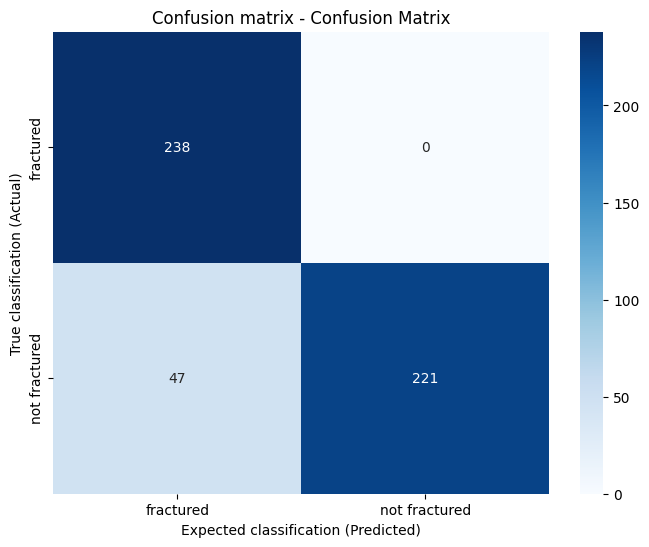

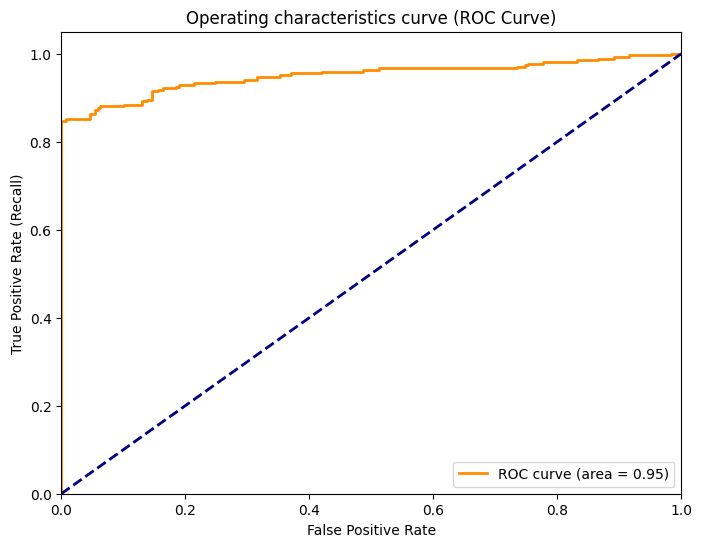

In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Correcting the test_dir path for Colab environment
test_dir = os.path.join(base_path, 'Bone_Fracture_Binary_Classification', 'Bone_Fracture_Binary_Classification', 'test')
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

def evaluate_medical_model(model, test_gen):

    test_gen.reset()
    y_pred_probs = model.predict(test_gen)
    y_pred_classes = (y_pred_probs > 0.5).astype(int).flatten()

    y_true = test_gen.classes
    class_labels = list(test_gen.class_indices.keys())

    print(f"\n {'*'*5} (Classification Report) {'*'*5}")
    print(classification_report(y_true, y_pred_classes, target_names=class_labels))

    cm = confusion_matrix(y_true, y_pred_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title('Confusion matrix - Confusion Matrix')
    plt.ylabel('True classification (Actual)')
    plt.xlabel('Expected classification (Predicted)')
    plt.show()

    fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate (Recall)')
    plt.title('Operating characteristics curve (ROC Curve)')
    plt.legend(loc="lower right")
    plt.show()

evaluate_medical_model(deep_model, test_generator)

from sklearn.utils import class_weight
import numpy as np
labels = df_final[df_final['Split'] == 'train']['Label'].map({'fractured': 1, 'not fractured': 0}).values
weights = class_weight.compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weights = dict(enumerate(weights))

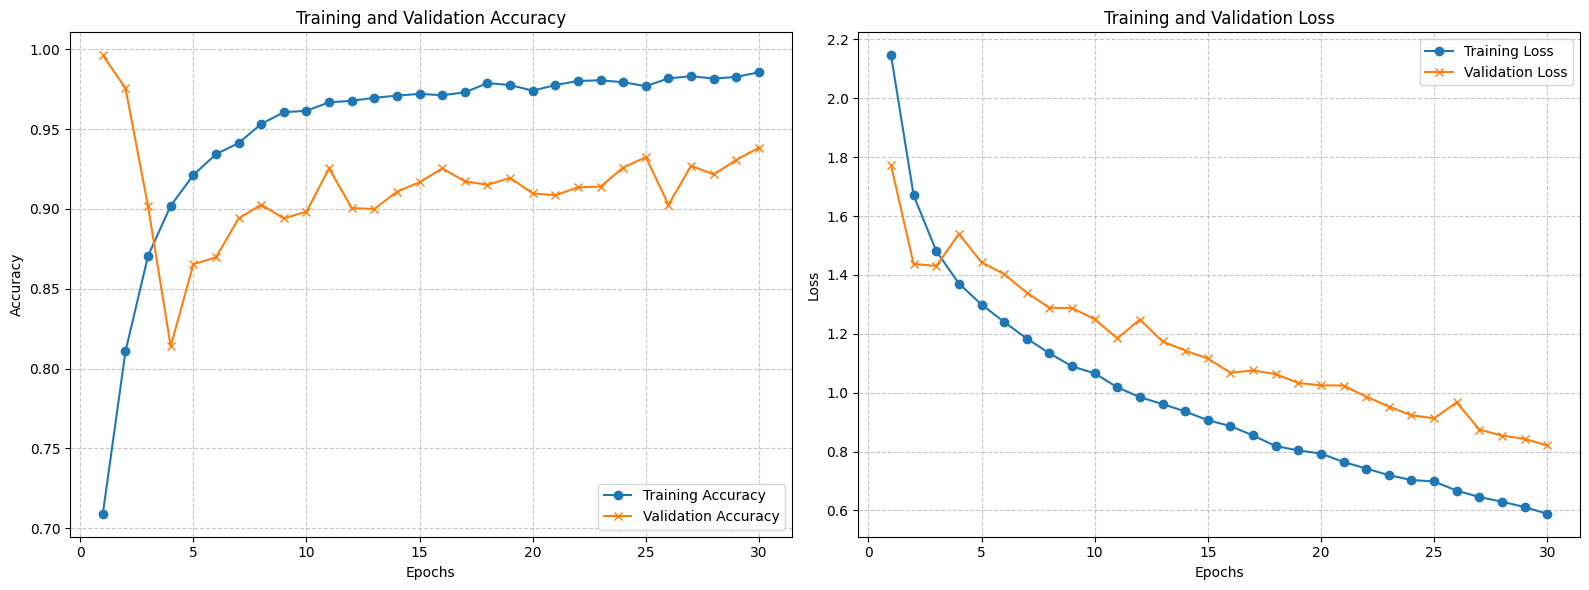

In [22]:
def plot_training_results(history):
    
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(16, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='x')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', marker='o')
    plt.plot(epochs_range, val_loss, label='Validation Loss', marker='x')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

plot_training_results(history)

In [34]:
train_generator = datagen.flow_from_dataframe(
    dataframe=train_df_final,
    x_col='Path',
    y_col='Label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training',
    shuffle=True
)

df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

print("The DataFrame data was successfully shuffled.")

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

def evaluate_with_shuffle_safety(model, test_gen):
    test_gen.reset()
    all_y_true = []
    all_y_pred = []

    for i in range(len(test_gen)):
        x_batch, y_batch = next(test_gen)
        preds = model.predict(x_batch, verbose=0)

        all_y_true.extend(y_batch)
        all_y_pred.extend((preds > 0.5).astype(int).flatten())

    print(classification_report(all_y_true, all_y_pred, target_names=list(test_gen.class_indices.keys())))

evaluate_with_shuffle_safety(deep_model, test_generator)

Found 7397 validated image filenames belonging to 2 classes.
The DataFrame data was successfully shuffled.
Found 506 images belonging to 2 classes.
               precision    recall  f1-score   support

    fractured       0.84      1.00      0.91       238
not fractured       1.00      0.82      0.90       268

     accuracy                           0.91       506
    macro avg       0.92      0.91      0.91       506
 weighted avg       0.92      0.91      0.91       506



16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 393ms/step

 ***** (Classification Report) *****
               precision    recall  f1-score   support

    fractured       0.84      1.00      0.91       238
not fractured       1.00      0.82      0.90       268

     accuracy                           0.91       506
    macro avg       0.92      0.91      0.91       506
 weighted avg       0.92      0.91      0.91       506



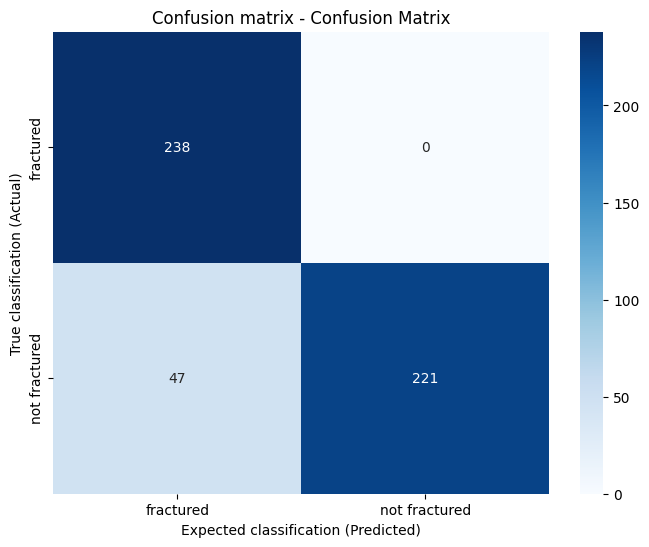

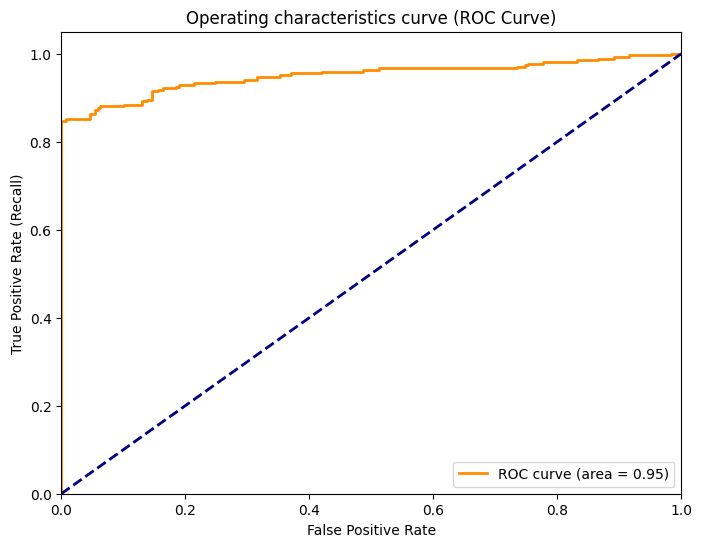

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


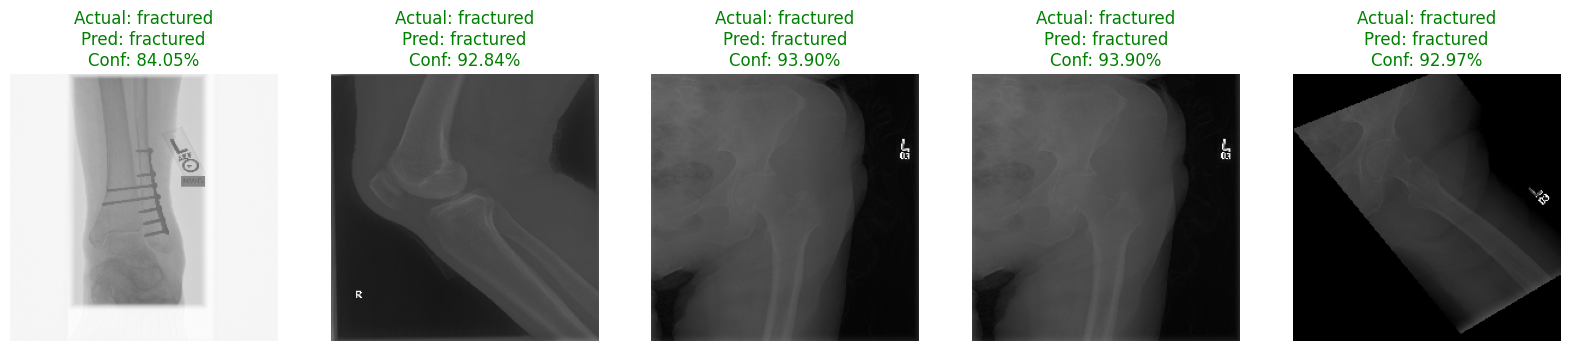

Found 506 images belonging to 2 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step


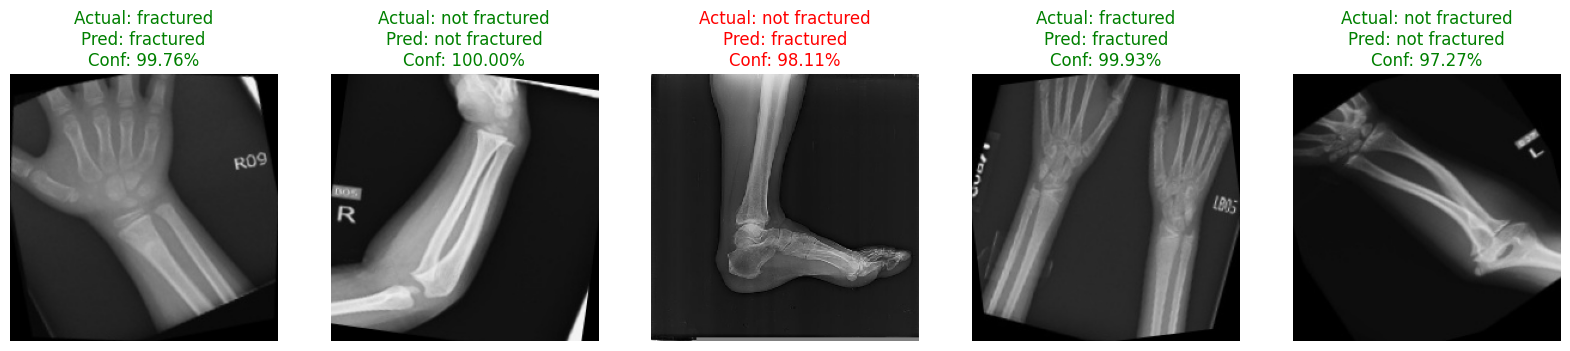

In [35]:
import numpy as np

test_generator.reset()
evaluate_medical_model(deep_model, test_generator)

def visualize_test_results(model, test_gen, num_samples=5):
    test_gen.reset()
    x_test, y_true = next(test_gen)

    y_pred_probs = model.predict(x_test)
    y_pred_classes = (y_pred_probs > 0.5).astype(int).flatten()

    class_labels = list(test_gen.class_indices.keys())

    plt.figure(figsize=(20, 10))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(x_test[i])

        actual_label = class_labels[int(y_true[i])]
        predicted_label = class_labels[y_pred_classes[i]]
        confidence = y_pred_probs[i][0] if y_pred_classes[i] == 1 else 1 - y_pred_probs[i][0]

        color = 'green' if actual_label == predicted_label else 'red'

        plt.title(f"Actual: {actual_label}\nPred: {predicted_label}\nConf: {confidence:.2%}", color=color)
        plt.axis('off')
    plt.show()

visualize_test_results(deep_model, test_generator, num_samples=5)
import numpy as np
from sklearn.utils import shuffle


df = pd.DataFrame(data_list)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=True,
    seed=42
)

visualize_test_results(deep_model, test_generator, num_samples=5)


In [36]:
test_generator.reset()
predictions = deep_model.predict(test_generator)
predicted_classes = (predictions > 0.5).astype(int).flatten()
true_classes = test_generator.classes

correct = np.sum(predicted_classes == true_classes)
total = len(true_classes)
accuracy = (correct / total) * 100

print(f"Total test images: {total}")
print(f"Correct predictions: {correct}")
print(f"False predictions: {total - correct}")
print(f"Final test accuracy: {accuracy:.2f}%")

16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 396ms/step
Total test images: 506
Correct predictions: 265
False predictions: 241
Final test accuracy: 52.37%
